# Week 3 실습

> "가입한 고객과 안 한 고객이 어떻게 다른지 한 장짜리 표로 정리해 주세요. 임원 보고용이라 숫자 하나씩만요." — 마케팅팀장

오늘 실습은 이 표를 만들어보려고 한다.  변수마다 "숫자 하나"를 고를 때 선택이 생기고, 그 선택에 따라 결론이 반대로 나오기도 하는데, 결론을 바꾸는 선택 세 가지를 찾는 것이 목표임.

| Part | 내용 | 셀 |
|---|---|---|
| 0 | 도입: 버클리 입학 데이터 | 실행 |
| 1 | 데이터 기술통계 확인 | 실행 |
| 2 | 변수의 척도 판정 | 빈칸, 해석 |
| 3 | 어떤 대표값을 쓸까 | 예측, 빈칸, 해석 |
| 4 | 코드값 하나가 대표값을 바꾼다 (`pdays`) | 예측, 빈칸, 해석 |
| 5 | 데이터에 없는 변수가 결론을 뒤집는다 (연도 복원)  | 예측, 빈칸, 해석 |
| 6 | 임원용 표 완성, AI와 비교 | 빈칸, 해석 |

셀 표시
- [실행] 실행만 하는 셀
- [빈칸] `TODO`를 채우는 셀
- [예측] 코드를 돌리기 전에 예상을 적는 칸. 틀린 예측도 기록해 둔다.
- [해석] 결과를 보고 해석을 적는 칸

LLM 사용 규칙: 문법과 에러는 자유롭게 사용 가능. 대신에, 방법 선택과 결과 해석은 [해석] 칸에 먼저 적은 뒤에만 사용. AI 비교는 Part 6에서 한 번에 진행할 예정


## 기본 세팅 [실행]

In [2]:
# 확인할 것: OK (45211, 18)이 출력되는지. 다르면 data/ 경로와 파일(bank-full.csv)을 확인한다.
import sys
sys.path.append("../..")   # weekNN_주제/<폴더>/ 기준 레포 루트 (README "처음 세팅" 참고)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats
from IPython.display import display

from common.load_data import load_bank, MONTH_ORDER

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100

# 그래프 한글 폰트: 설치된 한글 폰트 중 먼저 찾은 것을 쓴다 (Mac: AppleGothic, Windows: 맑은 고딕)
from matplotlib import font_manager
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Nanum Gothic", "Noto Sans CJK KR", "Noto Sans KR"]:
    if _font in _installed:
        plt.rcParams["font.family"] = _font
        break
else:
    print("한글 폰트를 찾지 못했어요. 그래프의 한글이 네모로 보이면 나눔고딕을 설치한 뒤 커널을 다시 시작하세요.")
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트에서 마이너스(-) 기호가 깨지지 않게

df = load_bank()                               # data/bank-full.csv, shape (45211, 17) 확인
df["sub"] = (df["y"] == "yes").astype(int)     # 가입=1, 미가입=0 (비율 계산용)
print("OK", df.shape)
# 행 순서가 곧 날짜 순서임. df를 정렬하거나 섞지 않도록~(Part 5 연도 복원에 필요).


OK (45211, 18)


---
## Part 0. 도입 — 버클리 대학원 입학 (1973) [실행]

1973년 UC 버클리 대학원 지원자 기록이다. 먼저 전체 합격률만 본다.

In [2]:
# 확인할 것: 전체 합격률이 남성 44.5%, 여성 30.4%로 약 14%p 차이 나는지.
ucb = pd.DataFrame({
    "dept":     list("ABCDEF"),
    "m_admit":  [512, 353, 120, 138, 53, 22],
    "m_apply":  [825, 560, 325, 417, 191, 373],
    "f_admit":  [89, 17, 202, 131, 94, 24],
    "f_apply":  [108, 25, 593, 375, 393, 341],
})
print(f"전체 합격률  남 {ucb.m_admit.sum() / ucb.m_apply.sum():.1%}  |  여 {ucb.f_admit.sum() / ucb.f_apply.sum():.1%}")


전체 합격률  남 44.5%  |  여 30.4%


이 숫자만 보고 여성 지원자가 차별받았다고 말할 수 있는가? (예 / 아니오 / 모르겠다)
- 모르겠다

In [3]:
# 확인할 것: 학과마다 m_rate와 f_rate 중 어느 쪽이 높은지, dept_rate가 낮은 학과에 f_share가 몰려 있는지.
ucb["m_rate"] = ucb.m_admit / ucb.m_apply
ucb["f_rate"] = ucb.f_admit / ucb.f_apply
ucb["dept_rate"] = (ucb.m_admit + ucb.f_admit) / (ucb.m_apply + ucb.f_apply)   # 학과 난이도
ucb["f_share"] = ucb.f_apply / ucb.f_apply.sum()                              # 여성 지원자가 어느 학과에 몰렸나
ucb["m_share"] = ucb.m_apply / ucb.m_apply.sum()
ucb[["dept", "dept_rate", "m_rate", "f_rate", "m_share", "f_share"]]


,dept,dept_rate,m_rate,f_rate,m_share,f_share
0,A,0.644,0.621,0.824,0.307,0.059
1,B,0.632,0.630,0.680,0.208,0.014
2,C,0.351,0.369,0.341,0.121,0.323
3,D,0.340,0.331,0.349,0.155,0.204
4,E,0.252,0.277,0.239,0.071,0.214
5,F,0.064,0.059,0.070,0.139,0.186


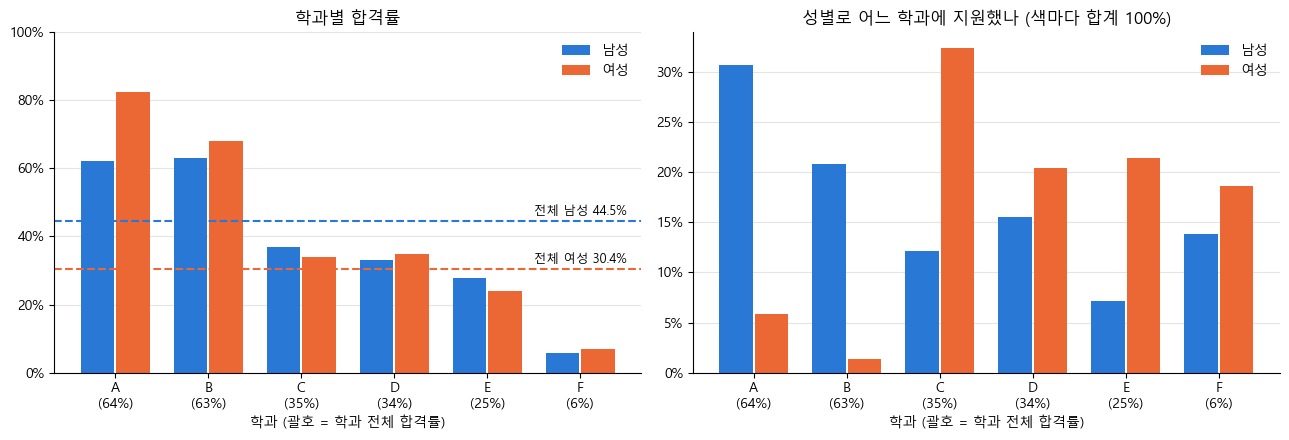

In [4]:
# 확인할 것: 왼쪽은 막대끼리 비슷한데 점선(전체)만 벌어지는지, 오른쪽은 여성 지원이 어려운 학과(C~F)에 몰리는지.
# 학과별 합격률(왼쪽)과 지원 비중(오른쪽). 두 값은 단위가 달라서 그래프를 나눠 그린다. [실행]
M_COLOR, F_COLOR = "#2a78d6", "#eb6834"
x = np.arange(len(ucb))
w = 0.36   # 막대 사이에 약간의 간격을 둔다
labels = [f"{d}\n({r:.0%})" for d, r in zip(ucb["dept"], ucb["dept_rate"])]   # 괄호 안 = 학과 전체 합격률
m_all = ucb.m_admit.sum() / ucb.m_apply.sum()
f_all = ucb.f_admit.sum() / ucb.f_apply.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.bar(x - 0.19, ucb["m_rate"], w, color=M_COLOR, label="남성")
ax1.bar(x + 0.19, ucb["f_rate"], w, color=F_COLOR, label="여성")
ax1.axhline(m_all, color=M_COLOR, lw=1.5, ls="--")
ax1.axhline(f_all, color=F_COLOR, lw=1.5, ls="--")
ax1.text(x[-1] + 0.5, m_all + 0.01, f"전체 남성 {m_all:.1%}", ha="right", va="bottom", fontsize=9)
ax1.text(x[-1] + 0.5, f_all + 0.01, f"전체 여성 {f_all:.1%}", ha="right", va="bottom", fontsize=9)
ax1.set_ylim(0, 1)
ax1.set_title("학과별 합격률")

ax2.bar(x - 0.19, ucb["m_share"], w, color=M_COLOR, label="남성")
ax2.bar(x + 0.19, ucb["f_share"], w, color=F_COLOR, label="여성")
ax2.set_title("성별로 어느 학과에 지원했나 (색마다 합계 100%)")

for ax in (ax1, ax2):
    ax.set_xticks(x, labels)
    ax.set_xlabel("학과 (괄호 = 학과 전체 합격률)")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.grid(axis="y", color="#e5e4e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)

plt.tight_layout(); plt.show()


[해석] 학과별로 보면 무엇이 달라지는가? 전체 합격률은 왜 반대로 나왔는가? (한 줄)

- 학과별로 보면 여성의 합격률이 높은 경우가 더 많다. 학과마다 성비가 같지 않기 때문이다.

질문: 은행 데이터에서 "학과" 역할을 하는 변수는 무엇일까? 데이터에 없는 변수일 수도 있다. Part 5에서 다시 본다.
- 연도..?

---
## Part 1. 데이터 기술 통계 확인 [실행]

- 분석 전에 데이터에 무엇이 들어 있는지만 확인. 즉, 이 Part는 실행만!!!! 
- 가입자/미가입자 비교는 Part 3에서 직접 하므로 여기서는 넣지 않았음

### 1-1. 데이터 개요

| 항목 | 내용 |
|---|---|
| 출처 | UCI Bank Marketing — 포르투갈 한 은행의 정기예금 전화 마케팅 기록 |
| 기간 | 2008년 5월 ~ 2010년 11월. 행이 날짜 순서로 정렬되어 있음 (연도 열은 없음) |
| 단위 | 한 행 = 한 번의 캠페인 대상 기록. 고객 ID가 없어 같은 고객이 여러 번 나오는지는 알 수 없음 |
| 타깃 | `y` 정기예금 가입 여부 (yes / no) |
| 표본 | 은행이 골라서 전화한 고객만 있음 (D-002) |

### 1-2. 변수 설명 (UCI 공식 설명 기준)

| 변수 | 설명 |
|---|---|
| `age` | 나이 |
| `job` | 직업 (12개 범주) |
| `marital` | 결혼 여부 (divorced는 사별 포함) |
| `education` | 학력 (primary / secondary / tertiary / unknown) |
| `default` | 신용 불량 여부 |
| `balance` | 연평균 잔액 (유로) |
| `housing` | 주택 대출 여부 |
| `loan` | 개인 대출 여부 |
| `contact` | 연락 수단 (cellular / telephone / unknown) |
| `day` | 마지막 연락 날짜의 "일" |
| `month` | 마지막 연락 날짜의 "월" |
| `duration` | 마지막 통화 시간(초). 통화가 끝나야 알 수 있으므로 오늘은 설명용 비교에만 사용 |
| `campaign` | 이번 캠페인에서 이 고객에게 연락한 횟수 (마지막 연락 포함) |
| `pdays` | 이전 캠페인에서 마지막으로 연락한 뒤 지난 일수 (-1 = 이전에 연락한 적 없음) |
| `previous` | 이번 캠페인 전까지 이 고객에게 연락한 횟수 |
| `poutcome` | 이전 캠페인 결과 (failure / other / success / unknown) |
| `y` | 정기예금 가입 여부 |


### 1-3. 데이터가 어떻게 생겼지?

In [5]:
# 확인할 것: 값이 예상한 형태인지 (y는 yes/no, pdays에 -1, 범주형에 unknown).
#   첫 행 month가 may인지도 본다. 원본은 2008년 5월부터 날짜순이라, 첫 행이 may가 아니면
#   파일이 정렬·셔플된 것이고 Part 5 연도 복원이 틀어진다.
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,sub
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [6]:
# 확인할 것: 숫자형인데 고유값이 적은 변수, isnull은 0인데 값 예시에 unknown이 보이는 변수.
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "고유값 수": df.nunique(),
    "isnull 개수": df.isnull().sum(),
    "값 예시": [df[c].unique()[:5].tolist() for c in df.columns],
})
overview.drop(index="sub")


,dtype,고유값 수,isnull 개수,값 예시
age,int64,77,0,"[58, 44, 33, 47, 35]"
job,object,12,0,"[management, technician, entrepreneur, blue-co..."
marital,object,3,0,"[married, single, divorced]"
education,object,4,0,"[tertiary, secondary, unknown, primary]"
default,object,2,0,"[no, yes]"
balance,int64,7168,0,"[2143, 29, 2, 1506, 1]"
housing,object,2,0,"[yes, no]"
loan,object,2,0,"[no, yes]"
contact,object,3,0,"[unknown, cellular, telephone]"
day,int64,31,0,"[5, 6, 7, 8, 9]"


`isnull 개수`가 전부 0인데, 그러면 이 데이터에 결측이 없다고 할 수 있을까?? 1-6의 값 목록이랑 같이 확인

### 1-4. 타깃 분포

타깃은 분석에서 설명하거나 예측하려는 결과 변수다 (여기서는 `y` 가입 여부). 타깃 분포는 그 값이 어떤 비율로 나뉘어 있는지, 즉 yes와 no가 각각 몇 %인지다.

In [7]:
# 확인할 것: 가입(yes) 비율이 11.7%인지. 뒤에 나오는 모든 가입률을 이 기준선과 비교한다.
tgt = df["y"].value_counts().to_frame("건수")
tgt["비율"] = tgt["건수"] / len(df)
tgt

,건수,비율
y,,
no,39922,0.883
yes,5289,0.117


### 1-5. 수치형 변수 요약

In [9]:
# 확인할 것: mean과 50%의 차이(치우침), 75%와 max의 차이(극단값), min에 음수나 -1 같은 코드값이 있는지.
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.000,40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,45211.000,1362.272,3044.766,-8019.000,72.000,448.000,1428.000,102127.000
day,45211.000,15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,45211.000,258.163,257.528,0.000,103.000,180.000,319.000,4918.000
campaign,45211.000,2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,45211.000,40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,45211.000,0.580,2.303,0.000,0.000,0.000,0.000,275.000


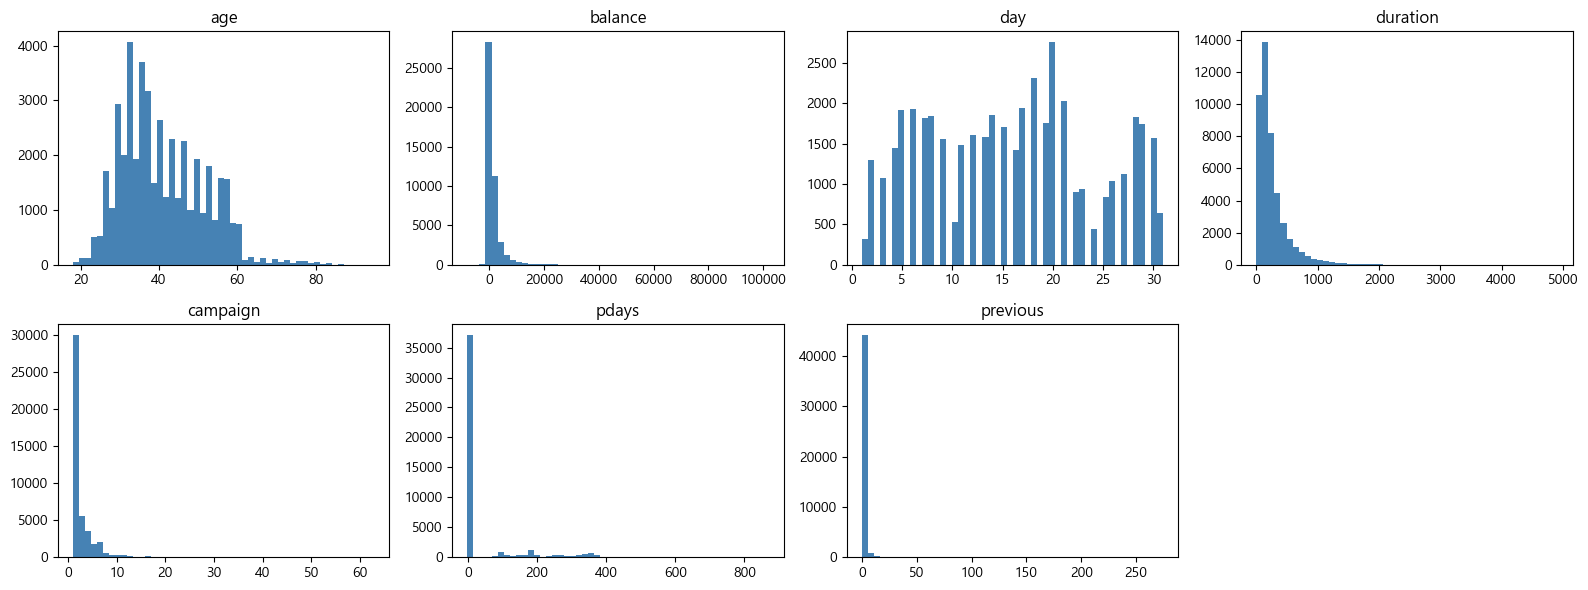

In [10]:
# 확인할 것: 봉우리 위치, 꼬리 방향과 길이, 한 값에 몰린 막대(pdays -1, previous 0), 극단값 때문에 축이 넓어진 변수.
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, c in zip(axes.flat, num_cols):
    ax.hist(df[c], bins=50, color="steelblue")
    ax.set_title(c)
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()


### 1-6. 범주형 변수 값 목록

In [11]:
# 확인할 것: unknown이 있는 변수와 그 비중, 한 범주에 몰린 변수 (default의 no, month의 may).
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
for c in cat_cols:
    vc = df[c].value_counts()
    print(f"[{c}] {vc.to_dict()}\n")


[job] {'blue-collar': 9732, 'management': 9458, 'technician': 7597, 'admin.': 5171, 'services': 4154, 'retired': 2264, 'self-employed': 1579, 'entrepreneur': 1487, 'unemployed': 1303, 'housemaid': 1240, 'student': 938, 'unknown': 288}

[marital] {'married': 27214, 'single': 12790, 'divorced': 5207}

[education] {'secondary': 23202, 'tertiary': 13301, 'primary': 6851, 'unknown': 1857}

[default] {'no': 44396, 'yes': 815}

[housing] {'yes': 25130, 'no': 20081}

[loan] {'no': 37967, 'yes': 7244}

[contact] {'cellular': 29285, 'unknown': 13020, 'telephone': 2906}

[month] {'may': 13766, 'jul': 6895, 'aug': 6247, 'jun': 5341, 'nov': 3970, 'apr': 2932, 'feb': 2649, 'jan': 1403, 'oct': 738, 'sep': 579, 'mar': 477, 'dec': 214}

[poutcome] {'unknown': 36959, 'failure': 4901, 'other': 1840, 'success': 1511}



### 1-7. 1차 메모 [해석] (2~3줄)

뒤에서 조심해야 할 것 같은 점만 적기. 뒤 Part에서 이 메모가 맞았는지 확인해보자.

- 히스토그램을 보면 변수중 대부분이 한쪽으로 치우쳐져 있다.


---
## Part 2. 변수의 척도 판정 [빈칸, 해석]

척도에 따라 쓸 수 있는 통계량이 정해지는데, 이때 어떻게 할지에 대한 근거 중심으로

척도가 뭔가요? 숫자가 "얼마나 많은 정보"를 담고 있는지의 수준이에요. 같은 숫자라도 무엇을 뜻하느냐에 따라 할 수 있는 계산이 달라요.
- 축구 등번호 10번과 5번: 숫자지만 이름표예요. "10번이 5번의 2배"라는 말은 뜻이 없어요. → 명목
- 달리기 1등, 2등, 3등: 순서는 있지만, 1등과 2등의 차이가 2등과 3등의 차이와 같다는 보장이 없어요. → 서열
- 섭씨 10도와 20도: 차이(10도)는 의미가 있지만, 0도가 "온도 없음"이 아니라서 "20도가 10도의 2배 따뜻하다"고 할 수 없어요. → 등간
- 나이 20세와 40세: 0세가 "없음"이라서 "40세는 20세의 2배"가 성립해요. → 비율

그래서 척도를 먼저 정해야 평균을 내도 되는지, 중앙값까지만 써야 하는지, 최빈값만 써야 하는지가 정해져요.

| 척도 | 할 수 있는 것 | 대표값 |
|---|---|---|
| 명목 | 같다/다르다 | 최빈값, 범주별 비율 |
| 서열 | + 순서 비교 | + 중앙값 |
| 등간 | + 차이(간격) 비교 | + 평균 |
| 비율 | + "몇 배" 비교 (0이 '없음'을 뜻함) | + 기하평균, 변동계수 |

판정할 때 확인할 질문
1. 값 사이에 순서가 있는가?
2. 1과 2의 차이가 10과 11의 차이와 같은 의미인가?
3. 0이 "하나도 없음"을 뜻하는가? ("2배"라는 말이 성립하는가?)
4. 숫자로 적혀 있지만 실제로는 이름표나 코드인 값이 있는가?

의견이 갈릴 만한 변수: `day`, `month`, `education`, `balance`, `pdays`. 하나로 떨어지지 않으면 "비율척도, 단 -1은 코드"처럼 조건을 붙여 적는다.


In [3]:
# 확인할 것: 판정마다 근거(질문 1~4 중 무엇)를 적었는지, day·month·education·balance·pdays에 조건을 붙였는지.
data_dictionary = pd.DataFrame([
    ("age",       "비율",                        "0세 = 없음, 40세는 20세의 2배"),
    ("job",       "명목",                        "순서 없는 범주"),
    ("marital",   "명목",                        "순서 없는 범주"),
    ("education", "서열 (unknown은 순서 밖)",      "primary < secondary < tertiary, 간격은 같지 않음"),
    ("default",   "명목 (이진)",                  "yes/no"),
    ("balance",   "비율 (음수 = 마이너스 잔액)",     "0유로 = 잔액 없음이라 절대 영점 있음. 단 음수가 있어 '몇 배' 비교는 양수끼리만"),
    ("housing",   "명목 (이진)",                  "yes/no"),
    ("loan",      "명목 (이진)",                  "yes/no"),
    ("contact",   "명목",                        "순서 없는 범주, unknown 포함"),
    ("day",       "등간처럼 보이나 순환형 (평균 무의미)", "31일 다음이 1일, 달마다 길이도 다름. 평균 15.8일은 해석 불가"),
    ("month",     "서열 (단, 순환형)",              "12월 다음이 1월, 연도도 섞여 있음. 월 평균은 무의미"),
    ("duration",  "비율",                        "0초 = 통화 없음"),
    ("campaign",  "비율 (이산 count)",             "0회 = 없음, 정수 count"),
    ("pdays",     "비율 + 코드값 혼합",             "0 이상은 일수(비율), -1은 '이전 연락 없음'이라는 범주 코드"),
    ("previous",  "비율 (이산 count)",             "0회 = 없음"),
    ("poutcome",  "명목",                        "unknown 대부분은 '이전 캠페인 없음'"),
    ("y",         "명목 (이진)",                  "yes/no"),
], columns=["variable", "scale", "reason"])
data_dictionary

,variable,scale,reason
0,age,비율,"0세 = 없음, 40세는 20세의 2배"
1,job,명목,순서 없는 범주
2,marital,명목,순서 없는 범주
3,education,서열 (unknown은 순서 밖),"primary < secondary < tertiary, 간격은 같지 않음"
4,default,명목 (이진),yes/no
5,balance,비율 (음수 = 마이너스 잔액),0유로 = 잔액 없음이라 절대 영점 있음. 단 음수가 있어 '몇 배' 비교는 양수끼리만
6,housing,명목 (이진),yes/no
7,loan,명목 (이진),yes/no
8,contact,명목,"순서 없는 범주, unknown 포함"
9,day,등간처럼 보이나 순환형 (평균 무의미),"31일 다음이 1일, 달마다 길이도 다름. 평균 15.8일은 해석 불가"


### 2-1. 척도가 틀리면 어떤 숫자가 나오는가 [빈칸]

아래 숫자는 모두 에러 없이 계산된다. 각각 보고서에 써도 되는 숫자인지 판단한다.

In [13]:
# 확인할 것: 세 숫자 모두 에러 없이 나온다는 점. 에러가 없다고 보고서에 쓸 수 있는 숫자는 아니다.
print("day 평균:", round(df["day"].mean(), 2))
print("month를 1~12로 바꾼 뒤 평균:", round(df["month"].map({m: i for i, m in enumerate(MONTH_ORDER, 1)}).mean(), 2))
print("job 최빈값:", df["job"].mode()[0])


day 평균: 15.81
month를 1~12로 바꾼 뒤 평균: 6.14
job 최빈값: blue-collar


[해석] 세 숫자 중 보고서에 쓸 수 있는 것과 없는 것, 그 이유

- day와 month는 숫자형태여도 날짜라서 평균이 의미가 없다. 쓸 수 있는 것은 job의 최빈값이다.

[해석] 척도 판정에서 의견이 갈린 변수와 각자의 근거

- 모두 day와 month를 부적합, job의 최빈값을 적합하다고 생각했다.


---
## Part 3. 어떤 대표값을 쓸까 [예측, 빈칸, 해석]

팀장은 "숫자 하나"를 원하기 때문에 그 숫자를 평균으로 하느냐 중앙값으로 하느냐에 따라 무엇이 달라지는지 확인해보자.

### 3-0. 예측 (코드 실행 전)

1-5의 히스토그램만 보고 적는다.

| 변수 | 가입자가 더 클까, 작을까? | 평균과 중앙값이 같은 방향일까? | 이유 |
|---|---|---|---|
| `age` | 비슷 | 아니요 | 분포가 30~40대에 몰려 있고 두 집단 차이가 작음 |
| `balance` | 더 크다 | 네 | 오른쪽으로 긴 분포라 평균이 중앙값보다 크다 |
| `duration` | 더 크다 | 네 | 오른쪽으로 긴 분포라 평균이 중앙값보다 크다 |
| `campaign` | 비슷 | 아니요 | 대부분 1~3회에 몰려있다. |


### 3-1. 가입자 vs 미가입자 대표값 비교표 [빈칸]

표 모양: 행 = 변수, 열 = 미가입 평균 / 가입 평균 / 미가입 중앙값 / 가입 중앙값 / 평균 방향 / 중앙값 방향 / 방향 일치 여부

방향은 가입자가 더 크면 `+`, 작으면 `-`, 같으면 `=`.

In [15]:
# 확인할 것: same_dir이 False인 변수, 그중 +와 -로 정반대인 변수가 무엇인지.
compare_cols = ["age", "balance", "duration", "campaign"]

g = df.groupby("y")[compare_cols]
summary = pd.DataFrame({
    "mean_no":    g.mean().loc["no"],
    "mean_yes":   g.mean().loc["yes"],
    "median_no":  g.median().loc["no"],
    "median_yes": g.median().loc["yes"],
})

sign = lambda d: np.where(d > 0, "+", np.where(d < 0, "-", "="))
summary["dir_mean"]   = sign(summary["mean_yes"] - summary["mean_no"])
summary["dir_median"] = sign(summary["median_yes"] - summary["median_no"])
summary["same_dir"]   = summary["dir_mean"] == summary["dir_median"]
summary



,mean_no,mean_yes,median_no,median_yes,dir_mean,dir_median,same_dir
age,40.839,41.670,39.000,38.000,+,-,False
balance,1303.715,1804.268,417.000,733.000,+,+,True
duration,221.183,537.295,164.000,426.000,+,+,True
campaign,2.846,2.141,2.000,2.000,-,=,False


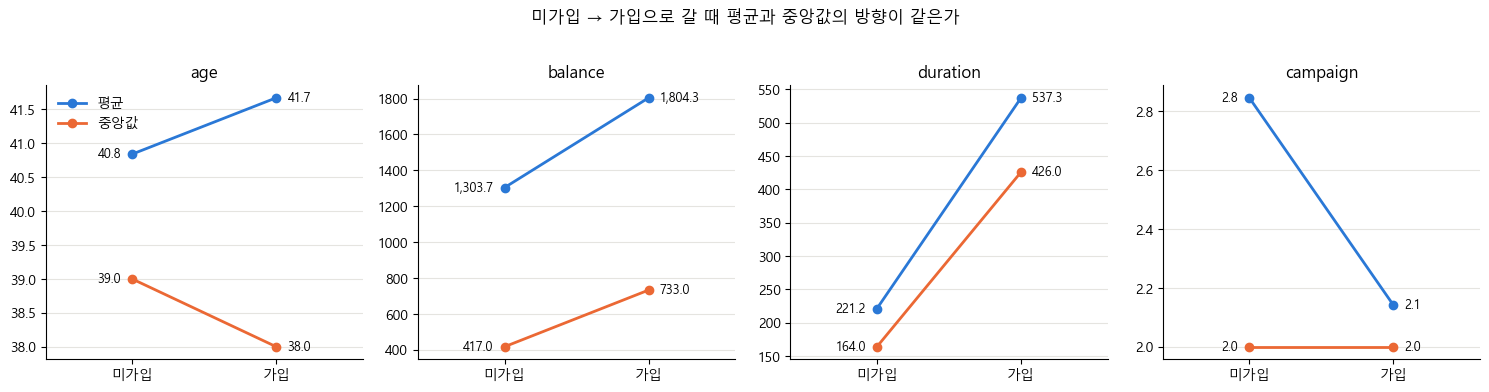

In [16]:
# 확인할 것: 두 선(평균, 중앙값)이 같은 방향으로 기울었는지. 반대로 기울면 대표값에 따라 결론이 바뀐다.
# 변수마다 미가입(no) → 가입(yes)으로 갈 때 평균과 중앙값이 어떻게 변하는지 선으로 잇는다.
# 선이 올라가면 가입자가 더 크고, 내려가면 더 작고, 수평이면 같다. 변수마다 단위가 달라 y축을 따로 쓴다.
MEAN_COLOR, MEDIAN_COLOR = "#2a78d6", "#eb6834"
g = df.groupby("y")[compare_cols]
means, medians = g.mean(), g.median()

fig, axes = plt.subplots(1, len(compare_cols), figsize=(15, 3.8))
for ax, col in zip(axes, compare_cols):
    for stat, color, name in [(means, MEAN_COLOR, "평균"), (medians, MEDIAN_COLOR, "중앙값")]:
        vals = [stat.loc["no", col], stat.loc["yes", col]]
        ax.plot([0, 1], vals, marker="o", color=color, lw=2, label=name)
        for xi, v in zip([0, 1], vals):
            ax.annotate(f"{v:,.1f}", (xi, v), textcoords="offset points",
                        xytext=(-8 if xi == 0 else 8, 0), ha="right" if xi == 0 else "left", va="center", fontsize=9)
    ax.set_xticks([0, 1], ["미가입", "가입"])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", lw=0.8)
axes[0].legend(frameon=False, loc="best")
fig.suptitle("미가입 → 가입으로 갈 때 평균과 중앙값의 방향이 같은가", y=1.02)
plt.tight_layout(); plt.show()


체크: `same_dir`이 `False`인 변수가 하나 이상 나와야 한다. 없다면 `median_yes - median_no`를 넣었는지 확인한다. `+`와 `-`로 반대인 경우와 한쪽이 `=`인 경우는 의미가 다르다.

[해석] 방향이 엇갈린 변수는 무엇인가? 이 상태로 "가입자가 나이가 더 많다/적다" 중 무엇이라고 보고할 수 있는가?

- 방향이 엇갈린 변수는 age, campaign이다. 방향이 다르다는 것은 한쪽으로 쏠려있을 가능성이 높기 때문에 가입자가 나이가 더 많거나 적다고 할 수 없다.


### 3-2. 왜 엇갈렸는가 — 분포 보기 [빈칸]

평균과 중앙값의 방향이 다르면 두 그룹의 분포 모양이 다르다는 뜻이다. 두 가지를 그린다.

1. 가입자/미가입자의 나이 분포를 같은 축에 겹쳐 그리기 (건수가 약 8배 차이 나므로 `density=True`)
2. 연령대별 가입률과 건수

구간은 `[17, 25, 30, 40, 50, 60, 100]`에서 시작하고, 양 끝 구간(25세 이하, 60세 초과)을 본다. 구간을 바꿔 봐도 된다. 어떤 구간을 왜 골랐는지는 PR에 적는다.

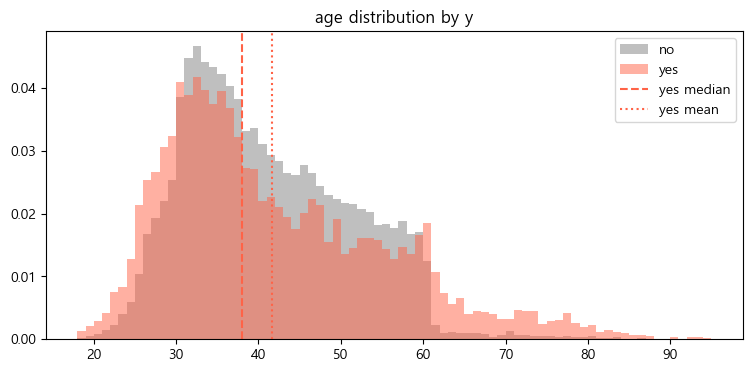

In [5]:
# 확인할 것: 한쪽 색만 드러난 나이대가 어디인지, 가입자 중앙값 선과 평균 선이 어느 쪽에 있는지.
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [("no", "gray"), ("yes", "tomato")]:
    ax.hist(df.loc[df.y == label, "age"], bins=range(18, 96), density=True, alpha=0.5, color=color, label=label)
ax.axvline(df.loc[df.y == "yes", "age"].median(), color="tomato", ls="--", label="yes median")
ax.axvline(df.loc[df.y == "yes", "age"].mean(),   color="tomato", ls=":",  label="yes mean")
ax.set_title("age distribution by y"); ax.legend(); plt.show()


In [7]:
# 확인할 것: 양 끝 구간의 sub_rate가 높은지, share_in_yes와 share_in_no가 양 끝에서 얼마나 다른지.
bins = [17, 25, 30, 40, 50, 60, 100]
df["age_band"] = pd.cut(df["age"], bins=bins)

band = df.groupby("age_band", observed=True).agg(
    n=("sub", "size"),
    sub_rate=("sub", "mean"),
)
band["share_in_yes"] = df[df.y == "yes"]["age_band"].value_counts(normalize=True).sort_index()
band["share_in_no"]  = df[df.y == "no"]["age_band"].value_counts(normalize=True).sort_index()
band


,n,sub_rate,share_in_yes,share_in_no
age_band,,,,
"(17, 25]",1336,0.240,0.061,0.025
"(25, 30]",5694,0.145,0.156,0.122
"(30, 40]",17687,0.102,0.343,0.398
"(40, 50]",11239,0.091,0.193,0.256
"(50, 60]",8067,0.101,0.153,0.182
"(60, 100]",1188,0.423,0.095,0.017


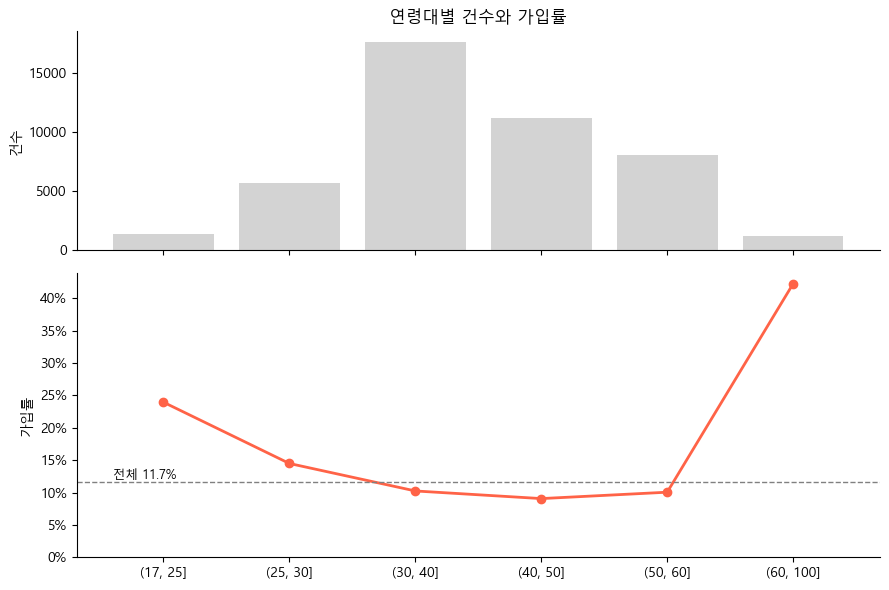

In [8]:
# 확인할 것: 가입률이 U자인지, 양 끝 구간의 건수가 가입률을 믿을 만큼 되는지.
# 위 = 건수, 아래 = 가입률. 단위가 달라서 y축을 하나씩 따로 쓴다 (가입률은 항상 건수와 같이 본다).
x = band.index.astype(str)
overall = df["sub"].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1.3]})
ax1.bar(x, band["n"], color="lightgray")
ax1.set_ylabel("건수")
ax1.set_title("연령대별 건수와 가입률")

ax2.plot(x, band["sub_rate"], marker="o", color="tomato", lw=2)
ax2.axhline(overall, color="gray", lw=1, ls="--")
ax2.text(-0.4, overall, f"전체 {overall:.1%}", ha="left", va="bottom", fontsize=9)
ax2.set_ylim(0, None)
ax2.set_ylabel("가입률")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


[해석] 가입률 그래프는 어떤 모양인가? 그 모양으로 "평균은 가입자가 크고 중앙값은 가입자가 작은" 현상을 설명한다. (`share_in_yes`와 `share_in_no`를 근거로)

- 가입률 그래프는 U자 모형이다. 양끝에서 가입률이 높고 30~50대 가운데에서 낮다.

[해석] 임원 보고용 표에 `age`는 어떻게 넣어야 하는가? 숫자 하나로 충분한가?

- age는 숫자 하나로 요약하지 않고 평균, 중앙값을 함께 적고 연령대별 가입률 표를 추가로 첨부한다. -> 젊은 층과 고령층에서 가입률이 높다는 결과를 전달해야한다.


### 3-3. `balance` — 전형적인 고객은 누구인가 [빈칸]

1-5에서 `balance`의 평균과 중앙값이 크게 달랐다. 대표값 후보를 모두 놓고 비교한다.

In [9]:
# 확인할 것: 평균·중앙값·최빈값이 얼마나 다른지, mean/median 배수, 음수와 0의 비율.
b = df["balance"]
bal = pd.Series({
    "mean":            b.mean(),
    "median":          b.median(),
    "mode":            b.mode()[0],
    "mean / median":   b.mean() / b.median(),
    "skew":            stats.skew(b),
    "음수 비율":        (b < 0).mean(),
    "0 비율":           (b == 0).mean(),
    "상위 1% 경계값":    b.quantile(0.99),
})
bal.to_frame("balance")


,balance
mean,1362.272
median,448.000
mode,0.000
mean / median,3.041
skew,8.360
음수 비율,0.083
0 비율,0.078
상위 1% 경계값,13164.900


In [10]:
# 확인할 것: 이 비율이 50%보다 훨씬 크면 평균은 전형적인 고객을 대표하지 못한다.
# 평균보다 잔액이 적은 고객은 몇 %일까?
print(f"평균({b.mean():.0f})보다 잔액이 적은 고객 비율: {(b < b.mean()).mean():.1%}")


평균(1362)보다 잔액이 적은 고객 비율: 74.0%


[해석] 평균, 중앙값, 최빈값은 각각 어떤 고객을 가리키는가? "우리 고객의 잔액은 보통 ○○유로"라고 한다면 ○○에 무엇을 넣고, 근거는 무엇인가?

- 평균은 잔액이 아주 큰 소수의 고객에 따라 올라간 값이고 중앙값은 순서대로 따졌을때 가운데 고객이다. 최빈값은 가장 많이 나온 값인데 이 데이터에서는 0이다. 따라서 우리 고객의 잔액은 보통 중앙값인 450유로라고 할 수 있다. 오른쪽으로 크게 치우친 분포이기 때문이다.


### 3-4. 경험법칙(68-95-99.7)이 `balance`에도 맞는가 [빈칸]

평균 ± kσ 안에 들어오는 비율을 세고, 정규분포 기준(경험법칙), 체비셰프 하한(1 − 1/k²)과 나란히 놓는다.

예측: `balance`에서 ±1σ 안에 들어오는 비율은 68%보다 많을까, 적을까? → (    )

In [11]:
# 확인할 것: ±1σ 안이 68%보다 많은지 적은지, ±3σ 밖이 0.3%보다 많은지, 체비셰프 하한은 지켜지는지.
m, s = b.mean(), b.std()
rows = []
for k, normal in [(1, 0.683), (2, 0.954), (3, 0.997)]:
    inside = ((b - m).abs() <= k * s).mean()
    rows.append((f"±{k}σ", inside, normal, 1 - 1 / k**2))
rule = pd.DataFrame(rows, columns=["범위", "balance 실제", "정규(경험법칙)", "체비셰프 하한"]).set_index("범위")
(rule * 100).round(1)


,balance 실제,정규(경험법칙),체비셰프 하한
범위,,,
±1σ,92.300,68.300,0.000
±2σ,96.800,95.400,75.000
±3σ,98.400,99.700,88.900


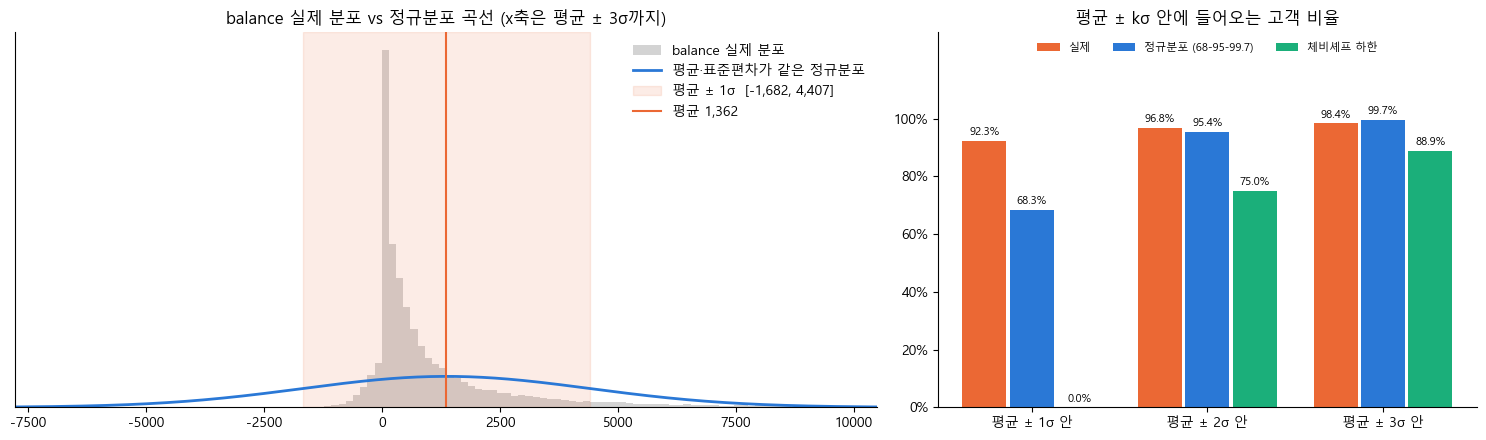

In [12]:
# 확인할 것: 회색(실제)이 파란 곡선(정규분포)보다 가운데에 훨씬 뾰족하게 몰려 있는지, 오른쪽에서 실제 비율이 68-95-99.7과 얼마나 다른지.
# 왼쪽: balance 분포(회색)와, 평균·표준편차가 같은 정규분포(파란 곡선)를 겹쳐 그린다. 주황 음영이 평균 ± 1σ 구간.
#       x축은 평균 ± 3σ까지만 보여준다 (이 밖에 약 1.6%가 더 있음).
# 오른쪽: 평균 ± kσ 안에 들어오는 비율을 실제 / 정규분포(경험법칙) / 체비셰프 하한으로 비교한다.
b = df["balance"]
m, s = b.mean(), b.std()
lo, hi = m - 3 * s, m + 3 * s
n_bins = 120
bin_w = (hi - lo) / n_bins
inside_view = b[(b >= lo) & (b <= hi)]
xs = np.linspace(lo, hi, 400)

ks = [1, 2, 3]
actual = [((b - m).abs() <= k * s).mean() for k in ks]
normal = [0.683, 0.954, 0.997]
cheb = [1 - 1 / k**2 for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1.6, 1]})

ax1.hist(inside_view, bins=n_bins, range=(lo, hi), weights=np.full(len(inside_view), 1 / (len(b) * bin_w)),
         color="lightgray", label="balance 실제 분포")
ax1.plot(xs, stats.norm.pdf(xs, m, s), color="#2a78d6", lw=2, label="평균·표준편차가 같은 정규분포")
ax1.axvspan(m - s, m + s, color="#eb6834", alpha=0.12, label=f"평균 ± 1σ  [{m - s:,.0f}, {m + s:,.0f}]")
ax1.axvline(m, color="#eb6834", lw=1.5, label=f"평균 {m:,.0f}")
ax1.set_xlim(lo, hi)
ax1.set_yticks([])
ax1.set_title("balance 실제 분포 vs 정규분포 곡선 (x축은 평균 ± 3σ까지)")
ax1.legend(frameon=False, loc="upper right")

x = np.arange(len(ks))
for offset, vals, color, name in [(-0.27, actual, "#eb6834", "실제"),
                                  (0.0, normal, "#2a78d6", "정규분포 (68-95-99.7)"),
                                  (0.27, cheb, "#1baf7a", "체비셰프 하한")]:
    bars = ax2.bar(x + offset, vals, 0.25, color=color, label=name)
    ax2.bar_label(bars, labels=[f"{v:.1%}" for v in vals], fontsize=8, padding=2)
ax2.set_xticks(x, [f"평균 ± {k}σ 안" for k in ks])
ax2.set_ylim(0, 1.3)
ax2.set_yticks(np.arange(0, 1.01, 0.2))
ax2.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax2.set_title("평균 ± kσ 안에 들어오는 고객 비율")
ax2.legend(frameon=False, loc="upper center", ncol=3, fontsize=8)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


[해석] 어느 방향으로 벗어났는가? 왜 그런가? (σ를 계산할 때 극단값이 어떤 역할을 하는지 생각해 본다)

- σ안의 비율이 정규분포보다 더 크다. 3σ에서는 반대로 정규분포보다 작다. σ가 평균과의 차이를 제곱해서 계산하기 때문에 극단값의 영향을 크게 받아 그렇다.


---
## Part 4. 코드값 하나가 대표값을 바꾼다 — `pdays` [예측, 빈칸, 해석]

먼저 용어부터: 은행은 이번 정기예금 캠페인 전에도 여러 번 마케팅 캠페인(전화 영업)을 했어요. 그래서 어떤 고객은 이번에 처음 전화를 받았고, 어떤 고객은 예전 캠페인에서도 전화를 받은 적이 있어요. 이 "예전 캠페인"과 관련된 열이 세 개예요.
- `previous`: 이번 캠페인 전까지 이 고객에게 전화한 횟수
- `pdays`: 예전 캠페인에서 마지막으로 전화한 날로부터 며칠 지났는지
- `poutcome`: 예전 캠페인의 결과 (success / failure / other / unknown)

예전에 전화한 적이 없는 고객은 "며칠 지났는지"를 적을 수가 없어요. 그래서 빈칸 대신 `-1`이라고 적어 뒀어요. 이 고객이 전체의 82%예요.

`pdays = -1`은 "이전에 연락한 적 없음"을 뜻하는 코드다. 숫자처럼 보이지만 "-1일"이라는 뜻이 아니다.

예측: 가입자와 미가입자의 `pdays` 평균을 비교하면

| | 가입자가 더 클까, 작을까? |
|---|---|
| -1 포함 |가입자가 더 크다.|
| -1 제외 (이전 연락이 있었던 고객만) | 가입자가 더 작다|


In [13]:
# 확인할 것: -1 포함과 제외에서 가입자/미가입자 방향이 바뀌는지, 그 차이가 '이전 연락 있었던 비율'과 연결되는지.
has_prev = df["pdays"] != -1
print(f"-1 비율: {(~has_prev).mean():.1%}")

pd_tab = pd.DataFrame({
    "-1 포함 평균":  df.groupby("y")["pdays"].mean(),
    "-1 제외 평균":  df[has_prev].groupby("y")["pdays"].mean(),
    "-1 제외 중앙값": df[has_prev].groupby("y")["pdays"].median(),
    "이전 연락 있었던 비율": df.assign(has_prev=has_prev).groupby("y")["has_prev"].mean(),
})
pd_tab.loc["전체"] = [df["pdays"].mean(), df.loc[has_prev, "pdays"].mean(),
                     df.loc[has_prev, "pdays"].median(), has_prev.mean()]
pd_tab


-1 비율: 81.7%


,-1 포함 평균,-1 제외 평균,-1 제외 중앙값,이전 연락 있었던 비율
y,,,,
no,36.421,234.191,232.000,0.159
yes,68.703,192.522,181.000,0.360
전체,40.198,224.578,194.000,0.183


In [14]:
# 확인할 것: pdays == -1인 행이 거의 모두 poutcome == unknown인지, 예외가 몇 건인지.
# 참고: pdays == -1 과 poutcome == "unknown" 은 같은 고객들일까?
pd.crosstab(df["pdays"] == -1, df["poutcome"])


poutcome,failure,other,success,unknown
pdays,,,,
False,4901,1840,1511,5
True,0,0,0,36954


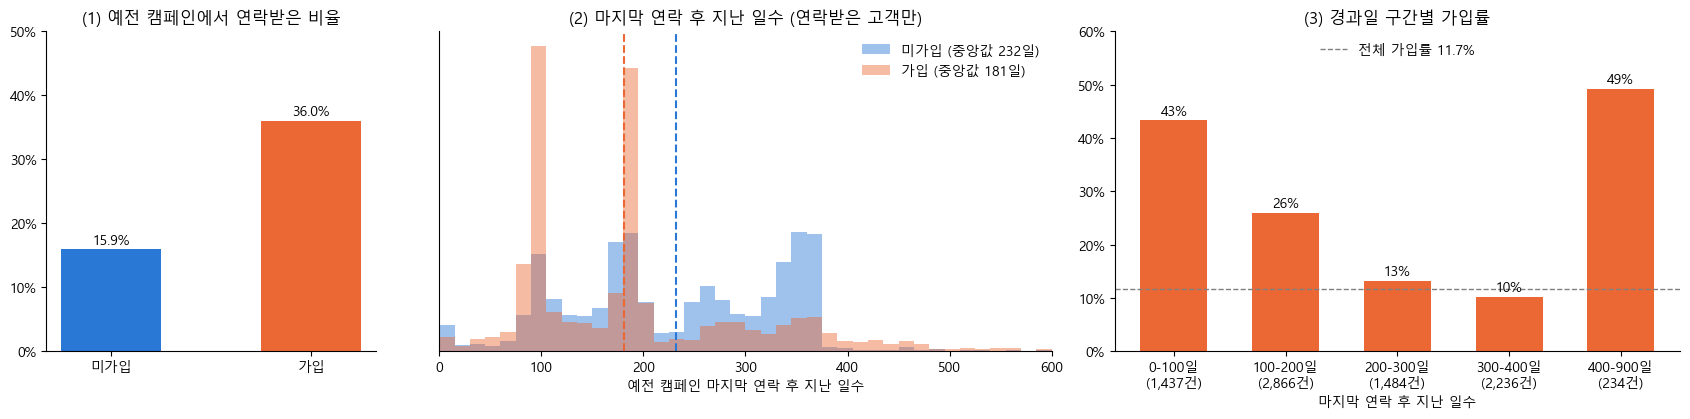

In [15]:
# 확인할 것: (1) 가입자 중 이전 연락 경험자가 더 많은지 (2) 경험자끼리 비교하면 가입자의 경과일이 더 짧은지 (3) 최근에 연락했을수록 가입률이 높은지.
# (1) 그룹별로 "이전 캠페인에서 연락받은 적 있는 고객" 비율 → -1 포함 평균이 사실상 이 비율을 재고 있었다
# (2) 이전 연락 경험자만 놓고, 마지막 연락 후 지난 일수 분포 (점선 = 중앙값)
# (3) 이전 연락 경험자를 경과일 구간으로 나눴을 때 이번 캠페인 가입률 (괄호 = 건수)
NO_COLOR, YES_COLOR = "#2a78d6", "#eb6834"
has_prev = df["pdays"] != -1
prev = df[has_prev]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={"width_ratios": [0.7, 1.3, 1.2]})

ax = axes[0]
share = df.assign(has_prev=has_prev).groupby("y")["has_prev"].mean()
bars = ax.bar(["미가입", "가입"], share.values, color=[NO_COLOR, YES_COLOR], width=0.5)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in share.values], padding=2)
ax.set_ylim(0, 0.5)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_title("(1) 예전 캠페인에서 연락받은 비율")

ax = axes[1]
for label, name, color in [("no", "미가입", NO_COLOR), ("yes", "가입", YES_COLOR)]:
    d = prev.loc[prev["y"] == label, "pdays"]
    ax.hist(d, bins=range(0, 601, 15), density=True, alpha=0.45, color=color, label=f"{name} (중앙값 {d.median():.0f}일)")
    ax.axvline(d.median(), color=color, ls="--", lw=1.5)
ax.set_xlim(0, 600)
ax.set_yticks([])
ax.set_xlabel("예전 캠페인 마지막 연락 후 지난 일수")
ax.set_title("(2) 마지막 연락 후 지난 일수 (연락받은 고객만)")
ax.legend(frameon=False)

ax = axes[2]
band = pd.cut(prev["pdays"], [0, 100, 200, 300, 400, 900])
rate = prev.groupby(band, observed=True)["sub"].agg(["mean", "size"])
labels = [f"{iv.left}-{iv.right}일\n({n:,}건)" for iv, n in zip(rate.index, rate["size"])]
bars = ax.bar(labels, rate["mean"], color=YES_COLOR, width=0.6)
ax.bar_label(bars, labels=[f"{v:.0%}" for v in rate["mean"]], padding=2)
ax.axhline(df["sub"].mean(), color="gray", lw=1, ls="--", label=f"전체 가입률 {df['sub'].mean():.1%}")
ax.legend(frameon=False, loc="upper center")
ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("마지막 연락 후 지난 일수")
ax.set_title("(3) 경과일 구간별 가입률")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


[해석] -1을 포함한 평균은 실제로 무엇을 재고 있었는가? (마지막 열 "이전 연락 있었던 비율"과 비교)

- -1을 포함한 평균은 이전 연락이 없었던 고객의 비율을 재고 있다.

[해석] 임원 보고용 표에 `pdays`를 넣는다면 어떤 형태로 넣는가?

- pdays는 이전 연락이 있었던 비율과 연락받은 고객만의 마지막 연락 후 경과일로 넣는다. 


---
## Part 5. 데이터에 없는 변수가 결론을 뒤집는다 — 연도 복원 [예측, 빈칸, 해석]

이 데이터에는 연도 열이 없다. 하지만 행이 날짜순이라는 설명과 `month` 열로 연도를 복원할 수 있다.

### 5-1. 연도 복원 [빈칸]

위에서부터 읽다가 월이 뒤로 돌아가면(dec → jan, nov → jan 등) 해가 바뀐 것으로 본다. 첫 해는 2008년(5월 시작).

1. `month`를 1~12 숫자로 바꾼다 (`MONTH_ORDER` 사용)
2. 바로 윗 행과의 차이(`diff()`)가 음수인 곳이 해가 바뀐 지점
3. 그 지점을 누적으로 세서(`cumsum()`) 2008에 더한다


In [16]:
# 확인할 것: 연도가 2008~2010 세 개로 나오는지, 건수가 2008년에 가장 많은지.
month_num = df["month"].map({m: i for i, m in enumerate(MONTH_ORDER, 1)})
year_change = month_num.diff() < 0   # 해가 바뀐 지점이면 True (이전 행보다 월 번호가 작아지면 새해)
df["year"] = 2008 + year_change.cumsum()   # 누적 합

df["year"].value_counts().sort_index()


year
2008    27729
2009    14862
2010     2620
Name: count, dtype: int64

검증: 복원이 맞았는지 확인한다. 아래 셀이 에러 없이 끝나야 한다.

In [17]:
# 확인할 것: '연도 복원 검증 통과'가 나오는지. 에러가 나면 year_change 조건과 행 순서를 확인한다.
# (1) 연도는 2008, 2009, 2010 세 개뿐이어야 한다 (더 많으면 정렬이 깨진 구간이 있다는 뜻)
assert sorted(df["year"].unique()) == [2008, 2009, 2010], df["year"].unique()
# (2) 첫 행은 2008년 5월, 마지막 행은 2010년 11월
assert (df["year"].iloc[0], df["month"].iloc[0]) == (2008, "may")
assert (df["year"].iloc[-1], df["month"].iloc[-1]) == (2010, "nov")
# (3) (연, 월, 일)로 만든 날짜가 한 번도 뒤로 가지 않아야 한다
date_key = df["year"] * 10000 + month_num * 100 + df["day"]
assert (date_key.diff().dropna() >= 0).all(), "날짜가 역행하는 행이 있음"
print("연도 복원 검증 통과")


연도 복원 검증 통과


### 5-2. 연도별 건수와 가입률 [빈칸]

예측: 세 해의 가입률이 비슷할까, 다를까? → (    )

In [18]:
# 확인할 것: 연도별 sub_rate 차이(약 5% → 52%)와 share_of_rows(2008년이 약 61%).
year_tab = df.groupby("year").agg(n=("sub", "size"), sub_rate=("sub", "mean"))
year_tab["share_of_rows"] = year_tab["n"] / year_tab["n"].sum()   # 전체 행 중 이 연도의 비율
year_tab

,n,sub_rate,share_of_rows
year,,,
2008,27729,0.051,0.613
2009,14862,0.171,0.329
2010,2620,0.516,0.058


[해석] 버클리 데이터의 "학과 난이도"와 "지원 비중"에 해당하는 것은 여기서 무엇인가?

- 학과 난이도: 연도별 가입률 / 지원 비중: 그룹별 연도 구성

[해석] 어떤 그룹의 전체 가입률은 연도별 가입률을 무엇으로 가중평균한 값인가? (교재 4.1 가중평균) 이 식으로 보면 전체 비교가 왜 뒤집힐 수 있는가?

- 그룹 전체의 가입률은 연도별 가입률을 그 그룹의 연도별 비중으로 가중평균한 값이다. 비교하는 두 그룹의 가중치가 다르면, 각 연도에서는 A가 높아도 A가 가입률이 낮은 해에 몰려있을 경우 전체로는 B가 더 높게 나올 수 있다. 전체 비교가 그룹 자체의 차이가 아니라 연도 구성의 차이를 반영하기 때문에 결론이 뒤집힐 수 있다.


### 5-3. 전체 비교 vs 연도별 비교 [예측, 빈칸]

아래 두 쌍을 비교한다. 먼저 전체 가입률로 어느 쪽이 높은지 적고, 그 다음 연도별로 나눈다.

| 비교 | 전체로 보면 어느 쪽이 높은가? (실행 후 기록) | 예측: 연도별로 나눠도 같을까? |
|---|---|---|
| `poutcome`: failure vs unknown | failure | 아니요 |
| `job`: technician vs admin. | admin | 아니요 |


In [19]:
# 확인할 것: 전체 차이와 연도별 차이의 부호가 반대인지, 연도별 건수가 너무 작은 칸은 없는지.
def simpson_check(col, a, b):
    """col의 두 범주 a, b를 전체 가입률 / 연도별 가입률 / 연도별 건수로 비교"""
    t = df[df[col].isin([a, b])]
    overall = t.groupby(col)["sub"].mean().rename("전체")
    by_year = t.pivot_table(index=col, columns="year", values="sub", aggfunc="mean")
    n_by_year = t.pivot_table(index=col, columns="year", values="sub", aggfunc="count")
    rate = pd.concat([overall, by_year], axis=1)

    diff = rate.loc[a] - rate.loc[b]
    flipped = (np.sign(diff["전체"]) != np.sign(diff.drop("전체"))).all()
    print(f"[{col}] {a} - {b} 가입률 차이:", diff.round(3).to_dict())
    print("→ 모든 연도에서 전체와 방향이 반대:", flipped)
    display(rate.round(3))
    display(n_by_year)

simpson_check("poutcome", "failure", "unknown")


[poutcome] failure - unknown 가입률 차이: {'전체': 0.034, 2008: -0.021, 2009: -0.069, 2010: -0.111}
→ 모든 연도에서 전체와 방향이 반대: True


,전체,2008,2009,2010
poutcome,,,,
failure,0.126,0.030,0.106,0.345
unknown,0.092,0.051,0.175,0.457


year,2008,2009,2010
poutcome,,,
failure,695,3569,637
unknown,26809,9250,900


In [20]:
# 확인할 것: poutcome보다 차이가 작아도 세 해 모두 방향이 반대인지.
simpson_check("job", "technician", "admin.")

[job] technician - admin. 가입률 차이: {'전체': -0.011, 2008: 0.002, 2009: 0.009, 2010: 0.063}
→ 모든 연도에서 전체와 방향이 반대: True


,전체,2008,2009,2010
job,,,,
admin.,0.122,0.049,0.167,0.455
technician,0.111,0.051,0.176,0.518


year,2008,2009,2010
job,,,
admin.,2878,1926,367
technician,5029,2188,380


### 5-4. 왜 뒤집혔는가 — 연도 구성 [빈칸]

버클리에서 어느 학과에 지원했는지 봤던 것처럼, 각 그룹이 어느 해에 몰려 있는지 확인한다.

In [22]:
# 확인할 것: 두 그룹이 몰려 있는 연도가 다른지 (unknown은 2008년, failure는 2009년).
# 각 그룹의 행이 연도별로 어떻게 나뉘는지 (행 기준 비율, 각 행의 합 = 1)
t = df[df["poutcome"].isin(["failure", "unknown"])]
pd.crosstab(t["poutcome"], t["year"], normalize="index").round(3)


year,2008,2009,2010
poutcome,,,
failure,0.142,0.728,0.130
unknown,0.725,0.250,0.024


### 5-5. 자유 탐색 [빈칸]

`simpson_check()`로 다른 조합도 시도하고, 뒤집히지 않은 경우도 기록한다. 심슨의 역설은 모든 조합에서 일어나지 않는다. 뒤집히지 않았다면 "연도를 통제해도 결론이 유지된다"는 결과다.

후보: `education` primary vs secondary, `marital` married vs divorced, `contact` cellular vs telephone, `job` retired vs student

In [ ]:
# 확인할 것: 뒤집힌 경우, 뒤집히지 않은 경우, 연도마다 다른 경우를 구분해 기록한다.
# simpson_check("TODO", "TODO", "TODO")
simpson_check("education", "primary", "secondary")
simpson_check("marital", "married", "divorced")
simpson_check("contact", "cellular", "telephone")
simpson_check("job", "retired", "student")

[education] primary - secondary 가입률 차이: {'전체': -0.019, 2008: -0.007, 2009: -0.013, 2010: -0.086}
→ 모든 연도에서 전체와 방향이 반대: False


,전체,2008,2009,2010
education,,,,
primary,0.086,0.043,0.133,0.437
secondary,0.106,0.050,0.146,0.523


year,2008,2009,2010
education,,,
primary,4503,2071,277
secondary,14297,7748,1157


[marital] married - divorced 가입률 차이: {'전체': -0.018, 2008: -0.025, 2009: -0.011, 2010: 0.037}
→ 모든 연도에서 전체와 방향이 반대: False


,전체,2008,2009,2010
marital,,,,
divorced,0.119,0.068,0.170,0.478
married,0.101,0.043,0.159,0.515


...

,전체,2008,2009,2010
contact,,,,
cellular,0.149,0.060,0.174,0.571
telephone,0.134,0.068,0.136,0.455


year,2008,2009,2010
contact,,,
cellular,13625,13559,2101
telephone,1339,1299,268


[job] retired - student 가입률 차이: {'전체': -0.059, 2008: -0.021, 2009: 0.064, 2010: -0.027}
→ 모든 연도에서 전체와 방향이 반대: False


,전체,2008,2009,2010
job,,,,
retired,0.228,0.052,0.318,0.509
student,0.287,0.074,0.254,0.536


year,2008,2009,2010
job,,,
retired,1050,821,393
student,176,540,222


[해석] 정리

| 비교 | 전체 결론 | 연도별 결론 | 뒤집혔나? | 이유 (연도 구성 근거) |
|---|---|---|---|---|
| poutcome failure vs unknown | failure가 높다. | 세 해 보두 unknown이 높다. | 뒤집힘 | unknown은 가입률이 가장 낮은 2008년에 몰려잇고, failure는 2009년에 몰려있다. 그래ㅓ failure의 전체 가입률이 연도 구성 덕에 올라가 보인다. |
| job technician vs admin. | admin이 높다. | 세 해 모두 technician이 높다. | 뒤집힘 | admin이 가입률이 높은 해에 더 많이 분포하고 technician은 2008년 비중이 더 크다. 차이가 작아서 연도 구성만으로도 순서가 바뀐다.  |
|  |  |  |  |  |

[해석] 토론: 데이터에 없는 변수(연도)가 결론을 뒤집을 수 있다면, 다음 데이터에서는 이를 어떻게 미리 의심할 수 있는가?

- 데이터가 시간순으로 정렬돼 있는데 연도열이 없다면 의심한다. 비교전에 그룹별 시기 구성을 crosstab으로 확인하고, 구성이 다르면 층별 가입률과 건수를 같이 본다. 연도별 가입률 수준이 크게 다르면 구성 차이만으로도 전체 비교가 뒤집힐 수 있기 때문이다.


---
## Part 6. 임원용 한 장짜리 표 완성 [빈칸, 해석]

지금까지 본 내용을 반영해 팀장에게 보낼 표를 만든다. 두 버전을 나란히 놓고 비교한다.

- 버전 A (describe 버전): 모든 수치 변수의 평균만 넣은 표. 가장 쉽게 만들 수 있다.
- 버전 B (내 버전): 변수마다 척도와 분포에 맞는 대표값을 고른 표.

버전 B 기준
- 수치형: 치우친 변수는 중앙값을 기본으로 하고, 평균과 크게 다르면 괄호로 병기
- 분포 모양이 핵심인 변수(`age`)는 숫자 하나 대신 연령대별 가입률 같은 표현도 가능
- 코드값이 섞인 변수(`pdays`)는 두 줄로 나눈다
- 범주형: 가입자/미가입자 각각에서 해당 범주의 비율 (예: 이전 캠페인 성공 고객 비율)
- 척도에 맞지 않는 변수(`day`, `month`)는 넣지 않거나 다른 형태로 넣는다
- 표 아래 각주 3줄: 누구에 대한 결과인지(D-002), 기간, 연도별 가입률 차이


In [24]:
# 확인할 것: day 평균, pdays 평균처럼 뜻이 없거나 반대로 읽히는 줄이 무엇인지.
# 버전 A — describe 버전 (실행만)
version_a = df.groupby("y")[["age", "balance", "day", "duration", "campaign", "pdays", "previous"]].mean().T
version_a.columns = ["미가입 평균", "가입 평균"]
version_a.round(1)


,미가입 평균,가입 평균
age,40.800,41.700
balance,1303.700,1804.300
day,15.900,15.200
duration,221.200,537.300
campaign,2.800,2.100
pdays,36.400,68.700
previous,0.500,1.200


In [26]:
# 확인할 것: 각 줄의 통계량이 척도와 분포에 맞는지, 버전 A와 인상이 달라지는 줄이 어디인지.
# 버전 B — 행을 직접 채운다. 값은 문자열로 적어도 된다 (예: "448 (평균 1,304)")
yes, no = df[df.y == "yes"], df[df.y == "no"]

def med_mean(s, d=0):
    """중앙값 (평균 ...) 형태의 문자열"""
    return f"{s.median():,.{d}f} (평균 {s.mean():,.{d}f})"

def contacted(d):
    """이전 캠페인에서 연락받은 고객만 (pdays != -1)"""
    return d.loc[d["pdays"] != -1, "pdays"]

version_b = pd.DataFrame([
    # 항목,                           미가입,   가입,    쓴 통계량 / 이유
    ("나이",
     med_mean(no["age"]), med_mean(yes["age"]),
     "중앙값(평균). 비율척도지만 가입률이 U자라 숫자 하나로는 부족 → 연령대별 가입률 표를 별도로 첨부"),
    ("연평균 잔액(유로)",
     med_mean(no["balance"]), med_mean(yes["balance"]),
     "중앙값(평균). 오른쪽으로 크게 치우쳐 평균이 소수의 고액 고객에 끌려감 → 중앙값이 전형적인 고객"),
    ("이전 캠페인 연락 경험 비율",
     f"{(no['pdays'] != -1).mean():.1%}", f"{(yes['pdays'] != -1).mean():.1%}",
     "비율. pdays=-1은 '연락 없음' 코드라 평균 대신 코드 여부의 비율로 환산"),
    ("(경험자 중) 이전 연락 후 경과일",
     f"{contacted(no).median():,.0f}일", f"{contacted(yes).median():,.0f}일",
     "중앙값. -1을 제외한 연락 경험자만 대상. 분포가 넓고 치우쳐 중앙값 사용"),
    ("이번 캠페인 연락 횟수",
     med_mean(no["campaign"], 1), med_mean(yes["campaign"], 1),
     "중앙값(평균). 대부분 1~3회에 몰리고 소수가 수십 회까지 가서 평균이 끌려감"),
    # 필요한 행 추가
], columns=["항목", "미가입", "가입", "통계량 / 이유"]).set_index("항목")
version_b


,미가입,가입,통계량 / 이유
항목,,,
나이,39 (평균 41),38 (평균 42),중앙값(평균). 비율척도지만 가입률이 U자라 숫자 하나로는 부족 → 연령대별 가입률...
연평균 잔액(유로),"417 (평균 1,304)","733 (평균 1,804)",중앙값(평균). 오른쪽으로 크게 치우쳐 평균이 소수의 고액 고객에 끌려감 → 중앙값...
이전 캠페인 연락 경험 비율,15.9%,36.0%,비율. pdays=-1은 '연락 없음' 코드라 평균 대신 코드 여부의 비율로 환산
(경험자 중) 이전 연락 후 경과일,232일,181일,중앙값. -1을 제외한 연락 경험자만 대상. 분포가 넓고 치우쳐 중앙값 사용
이번 캠페인 연락 횟수,2.0 (평균 2.8),2.0 (평균 2.1),중앙값(평균). 대부분 1~3회에 몰리고 소수가 수십 회까지 가서 평균이 끌려감


[해석] 각주 3줄
1. 이 결과는 은행이 전화로 연락한 고객 45,211명의 데이터다.
2. 기간은 2008년 5월 ~ 2010년 11월이다.
3. 연도별 가입률 차이가 크다.

[해석] 핵심 결과 한 줄 (PR 제목에 쓸 문장)

- 가입자는 이전 캠페인에서 연락받은 비율이 36%로 미가입자의 두배이상이다.

[해석] 버전 A를 그대로 보냈다면 팀장은 어떤 잘못된 결론을 내렸을까? 가장 위험한 줄 하나와 그 이유.

- 버전 A의 pdays 평균은 -1을 수자로 평균에 넣어 연락 경험 비율을 경과일로 오독하게 만든다. 연락받은 고객만 보면 가입자의 경과일이 더 짧아 방향이 반대이므로 팀장이 가입자는 연락한지 오래된 고객이라고 결론 내릴 위험이 크다.


### 6-1. AI와 비교 [빈칸, 해석]

내 분석을 끝낸 뒤, AI에게 아래 프롬프트를 그대로 넣고 결과를 점검한다.

> "bank-full.csv에서 가입자와 미가입자의 특성을 기술통계로 비교해줘."

| 점검 항목 | 통과 / 실패 | 근거 (AI 답변의 어느 부분) |
|---|---|---|
| `describe()` 평균만으로 비교하지 않았는가 | 실패 | 거의 평균으로 비교함 |
| 치우친 변수에 중앙값을 함께 제시했는가 | 통과 | 모든 변수의 중앙값 제시 |
| `day`·`month` 평균처럼 척도에 안 맞는 통계량을 내지 않았는가 | 실패 | day를 평균, 중앙값으로 통계내려 큰 차이 없다고함 |
| `pdays` -1을 코드로 인식하고 분리했는가 | 통과 | 이전에 접촉한 적이 없는 고객이 포함되어 잇음을 인지 |
| `age`의 평균·중앙값 방향 차이를 짚었는가 | 실패 | 평균, 중앙값 값만 보고 차이 크지 않다고 판단 |
| 표본 범위(연락받은 고객, 2008~2010)를 언급했는가 | 실패 | 총 명수만 언급하고 범위는 언급하지 않음 |
| 연도(시간) 같은 숨은 변수를 의심했는가 | 성공 | 월별 가입률을 비교함 |

[해석] AI와 내가 달랐던 점, 누가 맞았는지

- 나와 같았던 점: pdays=1을 평균으로 비교하기 어렵다고 알아채고 이전 접촉 경험 비율로 바꿨다, balance를 평균과 중앙값 둘다 제시했고 가입자가 높다는 방향도 같다.

- 나와 다르고 내가 맞았던 점: 
                            1. age : ai는 연령 차이는 크지 않음으로 끝냈다. 하지만 평균은 가입자가 더 크고 중앙값은 가입자가 더 작다. 평균과 중앙값의 방향이 엇갈리고 연령대별 가입률이 U자라는 점을 AI는 짚지 못했다.
                            2. day : ai는 평균, 중앙값을 그대로 표에 넣었다. 달력 날짜 코드라 평균이 의미가 없는데도 큰 차이 없음으로 해석했다.


---
## 마무리 [해석]

오늘의 결론 세 줄. 결론을 바꾼 세 가지 선택을 오늘 본 숫자로 적는다.

1. 어떤 대표값을 쓰느냐 → balance는 평균 1,804 vs 중앙값 733처럼 대표값에 따라 숫자가 달라진다.
2. 코드값을 넣느냐 → pdays -1을 넣으면 가입자가 더 커보이지만 연락받은 고객만 보면 반대다.
3. 어떤 단위로 나눠 보느냐 → 연도별로 나누면 가입률이 갈리고 전체비교가 뒤집힐수 있다.

PR 전 체크리스트 (이번 주 추가 항목)
- [ ] 척도에 맞지 않는 통계량을 쓰지 않았는가
- [ ] 치우친 변수를 평균만으로 요약하지 않았는가
- [ ] 코드값(-1, unknown)을 숫자나 정상값으로 취급하지 않았는가
- [ ] 전체 비교 결과가 하위 집단(연도)으로 나눠도 유지되는지 확인했는가
- [ ] 핵심 결과 한 줄이 노트북의 숫자와 일치하는가
- [ ] 노트북 출력 제거, 본인 폴더만 수정, 데이터 파일 없음
